In [ ]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)

import torch
from datasets import DatasetDict, Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
import evaluate
import pickle
from datasets import load_from_disk

warnings.filterwarnings("ignore")

In [ ]:
encoded_dataset = load_from_disk("title_classifier_encoded_dataset_headlines_only.hf")
# encoded_dataset.set_format("torch")

In [ ]:
device = (
    torch.device("mps")
    if torch.backends.mps.is_available()
    else torch.device("cuda")
    if torch.cuda.is_available()
    else torch.device("cpu")
)
print(device)

mps


In [4]:
encoded_dataset.set_format("torch", device=device)

## Load the Encoder

In [ ]:
import pickle

with open("./artifacts/02_y_encoder.pkl", "rb") as f:
    y_encoder = pickle.load(f)

## Finetuning Proper

In [6]:
labels = y_encoder.classes_
id2label = {idx: label for idx, label in enumerate(labels)}
label2id = {label: idx for idx, label in enumerate(labels)}
NUM_LABELS = len(labels)

In [ ]:
def compute_metrics(eval_pred):
    logits, true_labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    f1 = f1_score(true_labels, predictions, average="weighted")
    acc = accuracy_score(true_labels, predictions)
    return {"accuracy": acc, "f1": f1}

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
)

model = model.to(device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
WEIGHT_DECAY = 0.01
SEED = 69
BATCH_SIZE = 16
EPOCHS = 5
LEARNING_RATE = 2e-5
LOGGING_STEPS = 50

training_args = TrainingArguments(
    output_dir="./output/results_base_model_headlines_only",
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    num_train_epochs=EPOCHS,
    weight_decay=WEIGHT_DECAY,
    seed=SEED,
    logging_steps=LOGGING_STEPS,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["validation"],
    compute_metrics=compute_metrics,
)

In [11]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.031903,0.997999,0.713506,0.707644
2,0.860905,0.965992,0.723242,0.715538
3,0.689707,1.005607,0.725443,0.721983
4,0.438044,1.081790,0.724203,0.721470
5,0.344006,1.140489,0.722529,0.719739


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=40315, training_loss=0.7098535226885533, metrics={'train_runtime': 29759.9937, 'train_samples_per_second': 21.674, 'train_steps_per_second': 1.355, 'total_flos': 4.27402467571968e+16, 'train_loss': 0.7098535226885533, 'epoch': 5.0})

In [12]:
print("\nEvaluating on Test Set...")
print(trainer.evaluate(encoded_dataset["test"]))


Evaluating on Test Set...


{'eval_loss': 1.005791187286377, 'eval_accuracy': 0.7259332754557857, 'eval_f1': 0.722052852907855, 'eval_runtime': 467.8582, 'eval_samples_per_second': 86.169, 'eval_steps_per_second': 2.693, 'epoch': 5.0}


In [13]:
test_output = trainer.predict(encoded_dataset["test"])
predictions = np.argmax(test_output.predictions, axis=-1)
print(predictions)

[ 6 16  6 ... 14 16 22]


In [14]:
print(f"\n── Test set evaluation Headline + Short Description) ──")
test_output = trainer.predict(encoded_dataset["test"])
preds = np.argmax(test_output.predictions, axis=-1)


── Test set evaluation Headline + Short Description) ──


In [15]:
labels = test_output.label_ids

In [16]:
labels

array([14, 16,  6, ..., 12, 16, 22])

In [ ]:
report = classification_report(
    labels,
    preds,
    target_names=y_encoder.classes_,
    digits=4,
    zero_division=0,
)
print(report)

                precision    recall  f1-score   support

ARTS & CULTURE     0.5593    0.5651    0.5622       784
  BLACK VOICES     0.5477    0.5076    0.5269       916
      BUSINESS     0.6254    0.6359    0.6306      1549
        COMEDY     0.6030    0.5158    0.5560      1078
         CRIME     0.6388    0.5921    0.6146       711
       DIVORCE     0.8105    0.7251    0.7654       684
 ENTERTAINMENT     0.7233    0.7748    0.7482      3472
   ENVIRONMENT     0.5893    0.5850    0.5871       812
  FOOD & DRINK     0.7969    0.8026    0.7998      1687
 HOME & LIVING     0.7726    0.8159    0.7937       858
        IMPACT     0.4859    0.2974    0.3690       696
         MEDIA     0.6649    0.4388    0.5287       588
     PARENTING     0.7420    0.7121    0.7267      2532
      POLITICS     0.7925    0.8377    0.8145      7117
  QUEER VOICES     0.7822    0.6935    0.7352      1269
      RELIGION     0.5704    0.5914    0.5807       514
SCIENCE & TECH     0.5816    0.5728    0.5772  

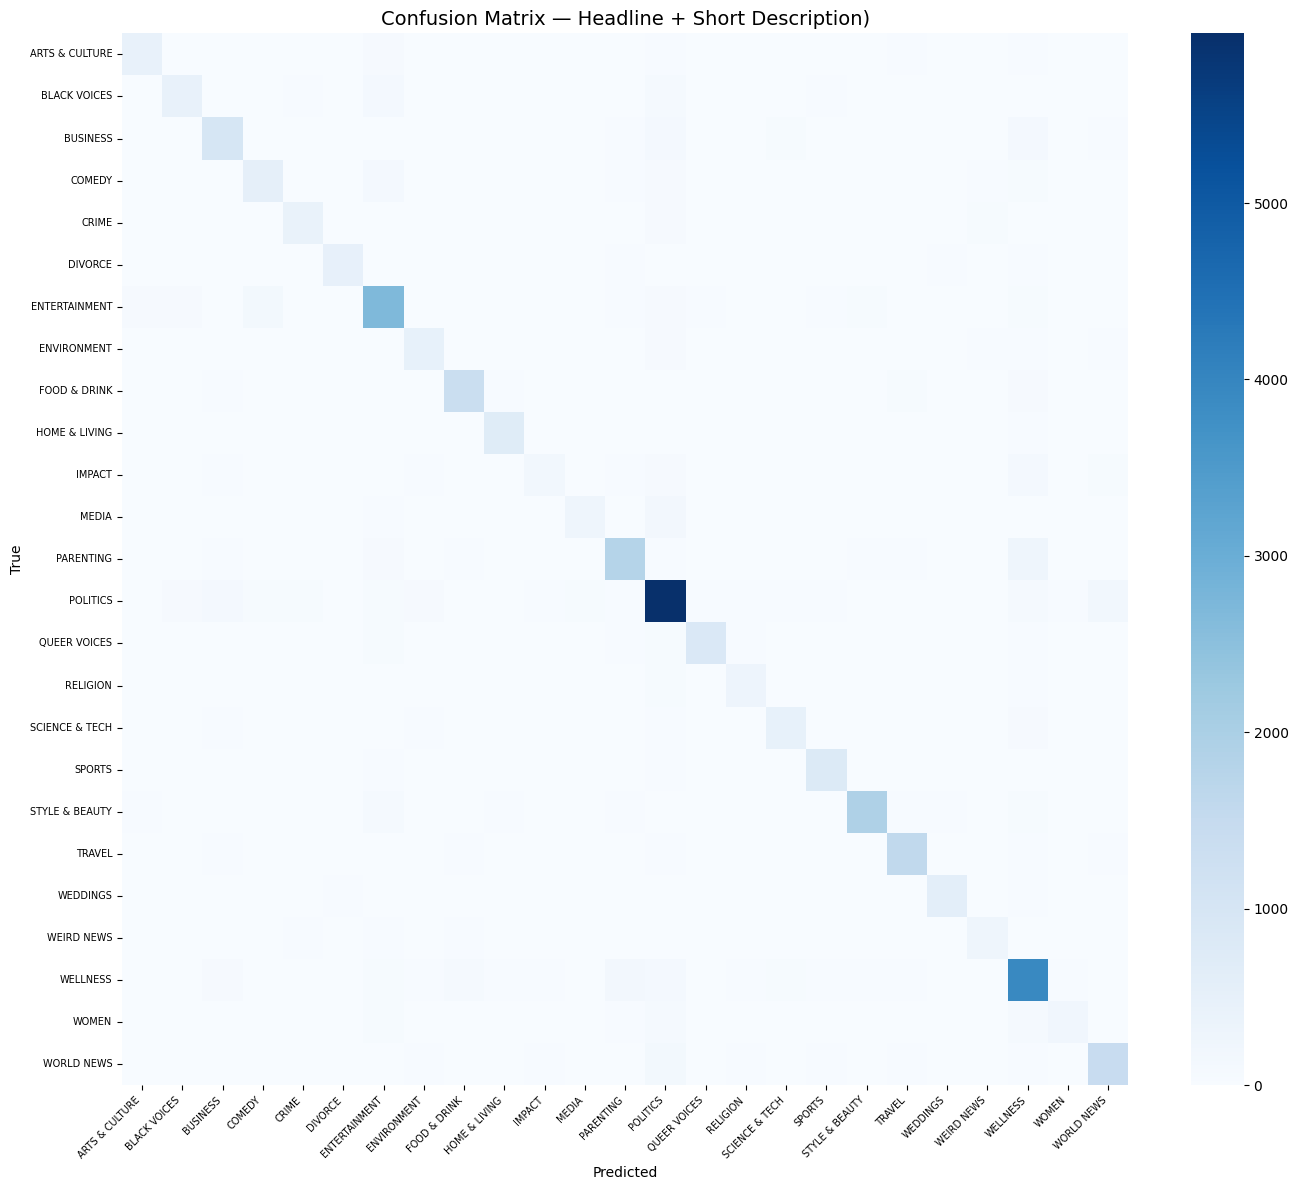

In [ ]:
cm = confusion_matrix(labels, preds)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm,
    annot=False,
    fmt="d",
    cmap="Blues",
    xticklabels=y_encoder.classes_,
    yticklabels=y_encoder.classes_,
    ax=ax,
)
ax.set_title(f"Confusion Matrix — Headline + Short Description)", fontsize=14)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()